# SpectralWaste

## functions

In [1]:
# ==================== CELL 1: FUNCTIONS ====================
import os, sys, yaml, torch, numpy as np
from pathlib import Path
from collections import OrderedDict
from PIL import Image
import matplotlib.pyplot as plt
from copy import deepcopy
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm

# Setup project root
PROJECT_ROOT = Path("/home/jon86439/BCAF")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from training_scripts.build_model import build_model_finetune
from training_scripts.dataload import create_datasets
from training_scripts.metrics import calculate_metrics

# ============= UTILITY FUNCTIONS =============

def get_palette_for_pil(num_classes=7):
    base = {
        0: [0, 0, 0],
        1: [218, 247, 6],
        2: [51, 221, 255],
        3: [52, 50, 221],
        4: [202, 152, 195],
        5: [0, 128, 0],
        6: [255, 165, 0],
    }
    palette = []
    for i in range(num_classes):
        palette.extend(base.get(i, [128, 128, 128]))
    if len(palette) < 768:
        palette.extend([0] * (768 - len(palette)))
    return palette[:768]

def denorm_image(t, modality='rgb'):
    if modality == 'rgb' and t.ndim == 3 and t.shape[0] == 3:
        mean = torch.tensor([0.485, 0.456, 0.406], device=t.device, dtype=t.dtype).view(3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225], device=t.device, dtype=t.dtype).view(3,1,1)
        return torch.clamp(t * std + mean, 0, 1)
    return torch.clamp(t, 0, 1) if t.dtype.is_floating_point else t

def cleanup_cuda(device=None, vars_to_del=None):
    import gc
    if vars_to_del:
        for v in vars_to_del:
            try: del v
            except: pass
    if torch.cuda.is_available():
        try:
            if device is not None and "cuda" in str(device):
                torch.cuda.synchronize(device)
            else:
                torch.cuda.synchronize()
        except Exception:
            pass
        torch.cuda.empty_cache()
    gc.collect()

def apply_shift_to_hsi(hsi_tensor, shift_x=0, shift_y=0):
    """Apply spatial shift to HSI tensor with zero-padding."""
    if shift_x == 0 and shift_y == 0:
        return hsi_tensor
    
    C, H, W = hsi_tensor.shape
    shifted = torch.zeros_like(hsi_tensor)
    
    src_y_start = max(0, -shift_y)
    src_y_end = min(H, H - shift_y)
    src_x_start = max(0, -shift_x)
    src_x_end = min(W, W - shift_x)
    
    tgt_y_start = max(0, shift_y)
    tgt_y_end = min(H, H + shift_y)
    tgt_x_start = max(0, shift_x)
    tgt_x_end = min(W, W + shift_x)
    
    shifted[:, tgt_y_start:tgt_y_end, tgt_x_start:tgt_x_end] = \
        hsi_tensor[:, src_y_start:src_y_end, src_x_start:src_x_end]
    
    return shifted

# ============= CHECKPOINT NORMALIZATION =============

def _normalize_and_augment(state_dict, target_keys):
    """Enhanced checkpoint normalization for various formats."""
    sd = state_dict
    if isinstance(sd, dict):
        for key in ["state_dict", "model_state_dict", "model"]:
            if key in sd and isinstance(sd[key], (dict, OrderedDict)):
                sd = sd[key]
                break
    
    cleaned = OrderedDict()
    def _strip_once(k):
        for p in ("module.", "_orig_mod.", "model.", "net.", "student.", "ema_model.", "unwrapped_model."):
            if k.startswith(p):
                return k[len(p):]
        return k
    
    for k, v in sd.items():
        nk = _strip_once(_strip_once(k))
        cleaned[nk] = v

    tgt = set(target_keys)
    aug = OrderedDict(cleaned)

    # Handle various backbone prefixing scenarios
    legacy_roots = ("patch_embed.", "layers.", "norm.", "pos_drop.", "seg_head.")
    
    if any(k.startswith("backbone.") for k in tgt):
        for k in list(cleaned.keys()):
            if k.startswith(legacy_roots):
                bk = "backbone." + k
                if bk not in aug: aug[bk] = cleaned[k]
    
    if any(k.startswith("rgb_model.backbone.") for k in tgt):
        for k in list(cleaned.keys()):
            if k.startswith(legacy_roots):
                rbk = "rgb_model.backbone." + k
                if rbk not in aug: aug[rbk] = cleaned[k]
        for k, v in list(cleaned.items()):
            if k.startswith("rgb_model.") and not k.startswith("rgb_model.backbone."):
                suffix = k[len("rgb_model."):]
                nk = "rgb_model.backbone." + suffix
                if nk not in aug: aug[nk] = v
    
    if any(k.startswith("hsi_model.backbone.") for k in tgt):
        for k in list(cleaned.keys()):
            if k.startswith(legacy_roots):
                hbk = "hsi_model.backbone." + k
                if hbk not in aug: aug[hbk] = cleaned[k]
        for k, v in list(cleaned.items()):
            if k.startswith("hsi_model.") and not k.startswith("hsi_model.backbone."):
                suffix = k[len("hsi_model."):]
                nk = "hsi_model.backbone." + suffix
                if nk not in aug: aug[nk] = v

    if not any(k.startswith("backbone.") for k in tgt):
        for k, v in list(aug.items()):
            if k.startswith("backbone."):
                stripped = k[len("backbone."):]
                if stripped not in aug: aug[stripped] = v
    
    return aug

# ============= MODEL LOADING =============

def build_and_load(config_path, checkpoint_path, device_id="0"):
    """Load model and dataset for evaluation."""
    device_id = str(device_id)
    
    with open(config_path, "r") as f:
        config = yaml.safe_load(f)

    config.setdefault("training", {})["compile_model"] = False
    config.setdefault("hardware", {})["gpu"] = device_id

    if torch.cuda.is_available():
        try:
            torch.cuda.set_device(int(device_id))
        except Exception:
            pass
        device = torch.device(f"cuda:{device_id}")
    else:
        device = torch.device("cpu")

    print(f"[GPU {device_id}] Loading dataset: {config['dataset_name']} (modality={config['modality']}) ...", flush=True)
    
    from contextlib import redirect_stdout
    with redirect_stdout(open(os.devnull, "w")):
        train_ds, val_ds, test_ds, num_classes, class_names = create_datasets(
            main_config=config,
            dataset_name=config["dataset_name"],
            data_modality_to_load=config["modality"],
            load_labelled_data=True
        )
    
    config["class_names"] = class_names
    print(f"[GPU {device_id}] Dataset loaded: test={len(test_ds)}, classes={num_classes}", flush=True)

    print(f"[GPU {device_id}] Loading model from checkpoint ...", flush=True)
    with redirect_stdout(open(os.devnull, "w")):
        model = build_model_finetune(config, num_classes)

    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(checkpoint_path)
    
    try:
        ckpt = torch.load(checkpoint_path, map_location="cpu", weights_only=True)
    except TypeError:
        ckpt = torch.load(checkpoint_path, map_location="cpu")

    tgt_sd = model.state_dict()
    cand_sd = _normalize_and_augment(ckpt, tgt_sd.keys())
    to_load = OrderedDict((k, v) for k, v in cand_sd.items()
                          if k in tgt_sd and tuple(tgt_sd[k].shape) == tuple(v.shape))
    model.load_state_dict(to_load, strict=False)

    model.to(device).eval()
    print(f"[GPU {device_id}] Model ready.", flush=True)
    return model, config, test_ds, num_classes, class_names, device

# ============= EVALUATION FUNCTIONS =============

def evaluate_full(
    model, config, test_ds, num_classes, device=None,
    batch_size=1, show_progress=False, device_id=None,
    clear_gpu=True, print_results=True, shift_x=0, shift_y=0
):
    """Evaluate model on test set with optional HSI shift."""
    import gc
    
    if device_id is None:
        device_id = os.environ.get("EVAL_GPU", "0")
    if device_id is not None and torch.cuda.is_available():
        try:
            torch.cuda.set_device(int(device_id))
        except Exception:
            pass
        device = torch.device(f"cuda:{device_id}")
    elif device is None:
        device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    model = model.to(device).eval()
    class_names = config.get("class_names", [f"class_{i}" for i in range(num_classes)])

    # Create dataloaders
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=0, pin_memory=torch.cuda.is_available()
    )
    
    # Create non-augmented loader for ground truth
    config_no_aug = deepcopy(config)
    config_no_aug.setdefault('augmentation', {})['enable'] = False
    _, _, test_dataset_for_labels, _, _ = create_datasets(
        main_config=config_no_aug,
        dataset_name=config['dataset_name'],
        data_modality_to_load=config.get('modality', 'rgb'),
        load_labelled_data=True
    )
    
    label_loader = DataLoader(
        test_dataset_for_labels, batch_size=batch_size,
        shuffle=False, num_workers=0, pin_memory=True
    )

    preds, labels = [], []
    total = len(test_loader)
    last_pct = -1
    
    if show_progress:
        print(f"[Eval] Evaluate model (shift_x={shift_x}, shift_y={shift_y})")
        print("[Eval] Progress: 0%", end="\r", flush=True)

    x = logits = pred = None
    try:
        with torch.no_grad():
            for i, (data_batch, label_batch) in enumerate(zip(test_loader, label_loader), 1):
                y = label_batch['label'].to(device, non_blocking=True)
                
                if config["modality"] == "rgb":
                    x = data_batch["image"].to(device, non_blocking=True)
                    logits = model(x)
                elif config["modality"] == "hsi":
                    x = data_batch["image"].to(device, non_blocking=True)
                    if shift_x != 0 or shift_y != 0:
                        x = torch.stack([apply_shift_to_hsi(x[b], shift_x, shift_y) for b in range(x.shape[0])])
                    logits = model(x)
                else:  # fusion
                    x_rgb = data_batch["rgb"].to(device, non_blocking=True)
                    x_hsi = data_batch["hsi"].to(device, non_blocking=True)
                    if shift_x != 0 or shift_y != 0:
                        x_hsi = torch.stack([apply_shift_to_hsi(x_hsi[b], shift_x, shift_y) for b in range(x_hsi.shape[0])])
                    x = {"rgb": x_rgb, "hsi": x_hsi}
                    logits = model(x)

                if logits.shape[2:] != y.shape[1:]:
                    logits = F.interpolate(logits, size=y.shape[1:], mode="bilinear", align_corners=False)
                
                preds.append(logits.argmax(1).cpu())
                labels.append(y.cpu())

                if show_progress and total > 0:
                    pct = int(i * 100 / total)
                    if pct > last_pct:
                        print(f"[Eval] Progress: {pct}%", end="\r", flush=True)
                        last_pct = pct
        
        if show_progress:
            print("[Eval] Progress: 100%")

        all_preds = torch.cat(preds).numpy()
        all_labels = torch.cat(labels).numpy()
        m = calculate_metrics(all_preds, all_labels, num_classes)

        if print_results:
            print(f"\n[Eval] === Results (shift_x={shift_x}, shift_y={shift_y}) ===")
            print(f"[Eval] mIoU: {m['miou']:.4f}")
            print("[Eval] Per-class IoU:")
            for ci, cname in enumerate(class_names):
                print(f"  IoU[{ci} - {cname}]: {m['class_iou'][ci]:.4f}")

        return m

    finally:
        if clear_gpu:
            try:
                model.to("cpu")
            except Exception:
                pass
            del x, logits, pred
            if torch.cuda.is_available():
                try:
                    torch.cuda.synchronize()
                except Exception:
                    pass
                torch.cuda.empty_cache()
            gc.collect()

# ============= VISUALIZATION FUNCTIONS =============

def visualize_grid(models_spec, input_idxs, device_id="0", shift_x=0, shift_y=0, 
                   title_fs=15, cell_w=3.0, cell_h=2.8):
    """Visualize predictions for multiple models with optional HSI shift."""
    palette = get_palette_for_pil(7)
    rows = len(input_idxs)
    cols = len(models_spec) + 2
    
    fig, axs = plt.subplots(
        rows, cols, figsize=(cell_w * cols, cell_h * rows),
        squeeze=False, gridspec_kw={'hspace': 0.03, 'wspace': 0.05}
    )

    axs[0, 0].set_title('Input\n', fontsize=title_fs)
    axs[0, 1].set_title('GT\n', fontsize=title_fs)

    legend_class_names = None

    for i, spec in enumerate(models_spec):
        print(f"Loading: {spec['name']} on GPU {device_id} (shift_x={shift_x}, shift_y={shift_y})")
        try:
            model, config, test_ds, num_classes, class_names, device = build_and_load(
                spec['config'], spec['checkpoint'], device_id=device_id
            )
            if legend_class_names is None:
                legend_class_names = class_names
                legend_num_classes = num_classes

            col = i + 2

            for r, idx in enumerate(input_idxs):
                if idx >= len(test_ds):
                    axs[r, col].text(0.5, 0.5, 'Idx OOB', ha='center', va='center',
                                     transform=axs[r, col].transAxes, fontsize=10)
                    axs[r, col].axis('off')
                    continue

                sample = test_ds[idx]
                with torch.no_grad():
                    if config["modality"] == "rgb":
                        x = sample["image"].unsqueeze(0).to(device)
                        logits = model(x)
                        vis_mod = "rgb"; img = sample["image"].cpu()
                    elif config["modality"] == "hsi":
                        x = sample["image"].unsqueeze(0).to(device)
                        if shift_x != 0 or shift_y != 0:
                            x = apply_shift_to_hsi(x[0], shift_x, shift_y).unsqueeze(0)
                        logits = model(x)
                        vis_mod = "hsi"; img = sample["image"].cpu()
                    else:  # fusion
                        x_rgb = sample["rgb"].unsqueeze(0).to(device)
                        x_hsi = sample["hsi"].unsqueeze(0).to(device)
                        if shift_x != 0 or shift_y != 0:
                            x_hsi = apply_shift_to_hsi(x_hsi[0], shift_x, shift_y).unsqueeze(0)
                        x = {"rgb": x_rgb, "hsi": x_hsi}
                        logits = model(x)
                        vis_mod = "rgb"; img = sample["rgb"].cpu()

                    if logits.shape[2:] != sample["label"].shape:
                        logits = torch.nn.functional.interpolate(
                            logits, size=sample["label"].shape, mode="bilinear", align_corners=False
                        )
                    pred = logits.argmax(1).squeeze().cpu()

                if i == 0:
                    img_disp = denorm_image(img, vis_mod)
                    if vis_mod == "rgb":
                        axs[r, 0].imshow(img_disp.permute(1, 2, 0).numpy())
                    else:
                        hsi_vis = (img_disp[:10].mean(0).numpy()
                                   if img_disp.ndim == 3 and img_disp.shape[0] >= 10
                                   else img_disp[0].numpy())
                        axs[r, 0].imshow(hsi_vis, cmap="gray")
                    axs[r, 0].axis("off")
                    
                    gt_p = Image.fromarray(sample["label"].numpy().astype(np.uint8), mode="P")
                    gt_p.putpalette(palette)
                    axs[r, 1].imshow(gt_p.convert("RGB"))
                    axs[r, 1].axis("off")

                pred_p = Image.fromarray(pred.numpy().astype(np.uint8), mode="P")
                pred_p.putpalette(palette)
                axs[r, col].imshow(pred_p.convert("RGB"))
                axs[r, col].axis("off")

            axs[0, col].set_title(spec['title'], fontsize=title_fs)

            try: model.to("cpu")
            except: pass
            cleanup_cuda(device=device, vars_to_del=["model", "x", "logits", "pred"])
            del model

        except Exception as e:
            print(f"Error loading {spec['name']}: {e}")
            col = i + 2
            for r in range(rows):
                axs[r, col].text(0.5, 0.5, 'Error', ha='center', va='center',
                                 transform=axs[r, col].transAxes, fontsize=10)
                axs[r, col].axis('off')
            axs[0, col].set_title(f"Error: {spec['title']}", fontsize=10)

    # Add legend
    if legend_class_names is not None:
        import matplotlib.patches as mpatches
        fig.tight_layout(pad=0.05, w_pad=0.05, h_pad=0.03)
        fig.canvas.draw()
        
        bottom_of_grid = min(ax.get_position().y0 for ax in axs.ravel())
        handles = []
        for ci in range(legend_num_classes):
            rgb = palette[ci*3:ci*3+3]
            color = tuple(v/255. for v in rgb)
            label = legend_class_names[ci] if ci < len(legend_class_names) else f"class_{ci}"
            handles.append(mpatches.Patch(color=color, label=label))
        
        gap = 0.004
        fig.legend(
            handles=handles, loc='upper center',
            bbox_to_anchor=(0.5, bottom_of_grid - gap),
            bbox_transform=fig.transFigure,
            ncol=legend_num_classes, frameon=False,
            fontsize=15, columnspacing=0.9, handlelength=1.6
        )
    else:
        fig.tight_layout(pad=0.05, w_pad=0.05, h_pad=0.03)

    plt.show()

print("✅ All functions loaded successfully!")

✅ All functions loaded successfully!


## visualize

COMPUTING METRICS FOR VISUALIZATION MODELS

=== RGB-256
(Origin 256) | GPU 6 ===
[GPU 6] Loading dataset: SpectralWaste (modality=rgb) ...
[GPU 6] Dataset loaded: test=171, classes=7
[GPU 6] Loading model from checkpoint ...
[GPU 6] Model ready.
SpectralWasteDataset (rgb, train): 514 files
SpectralWasteDataset (rgb, val): 167 files
SpectralWasteDataset (rgb, test): 171 files
Loaded 'SpectralWaste' | train=514 val=167 test=171 classes=7
[Eval] Evaluate model (shift_x=0, shift_y=0)
[Eval] Progress: 100%

[Eval] === Results (shift_x=0, shift_y=0) ===
[Eval] mIoU: 0.6611
[Eval] Per-class IoU:
  IoU[0 - background]: 0.9205
  IoU[1 - film]: 0.7577
  IoU[2 - basket]: 0.7856
  IoU[3 - cardboard]: 0.7596
  IoU[4 - video_tape]: 0.3923
  IoU[5 - filament]: 0.5956
  IoU[6 - bag]: 0.6761

=== RGB-1024
(Origin 256) | GPU 6 ===
[GPU 6] Loading dataset: SpectralWaste (modality=rgb) ...
[GPU 6] Dataset loaded: test=171, classes=7
[GPU 6] Loading model from checkpoint ...
[GPU 6] Model ready.
SpectralWa

/tmp/ipykernel_1078901/617407574.py:432: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.05, w_pad=0.05, h_pad=0.03)


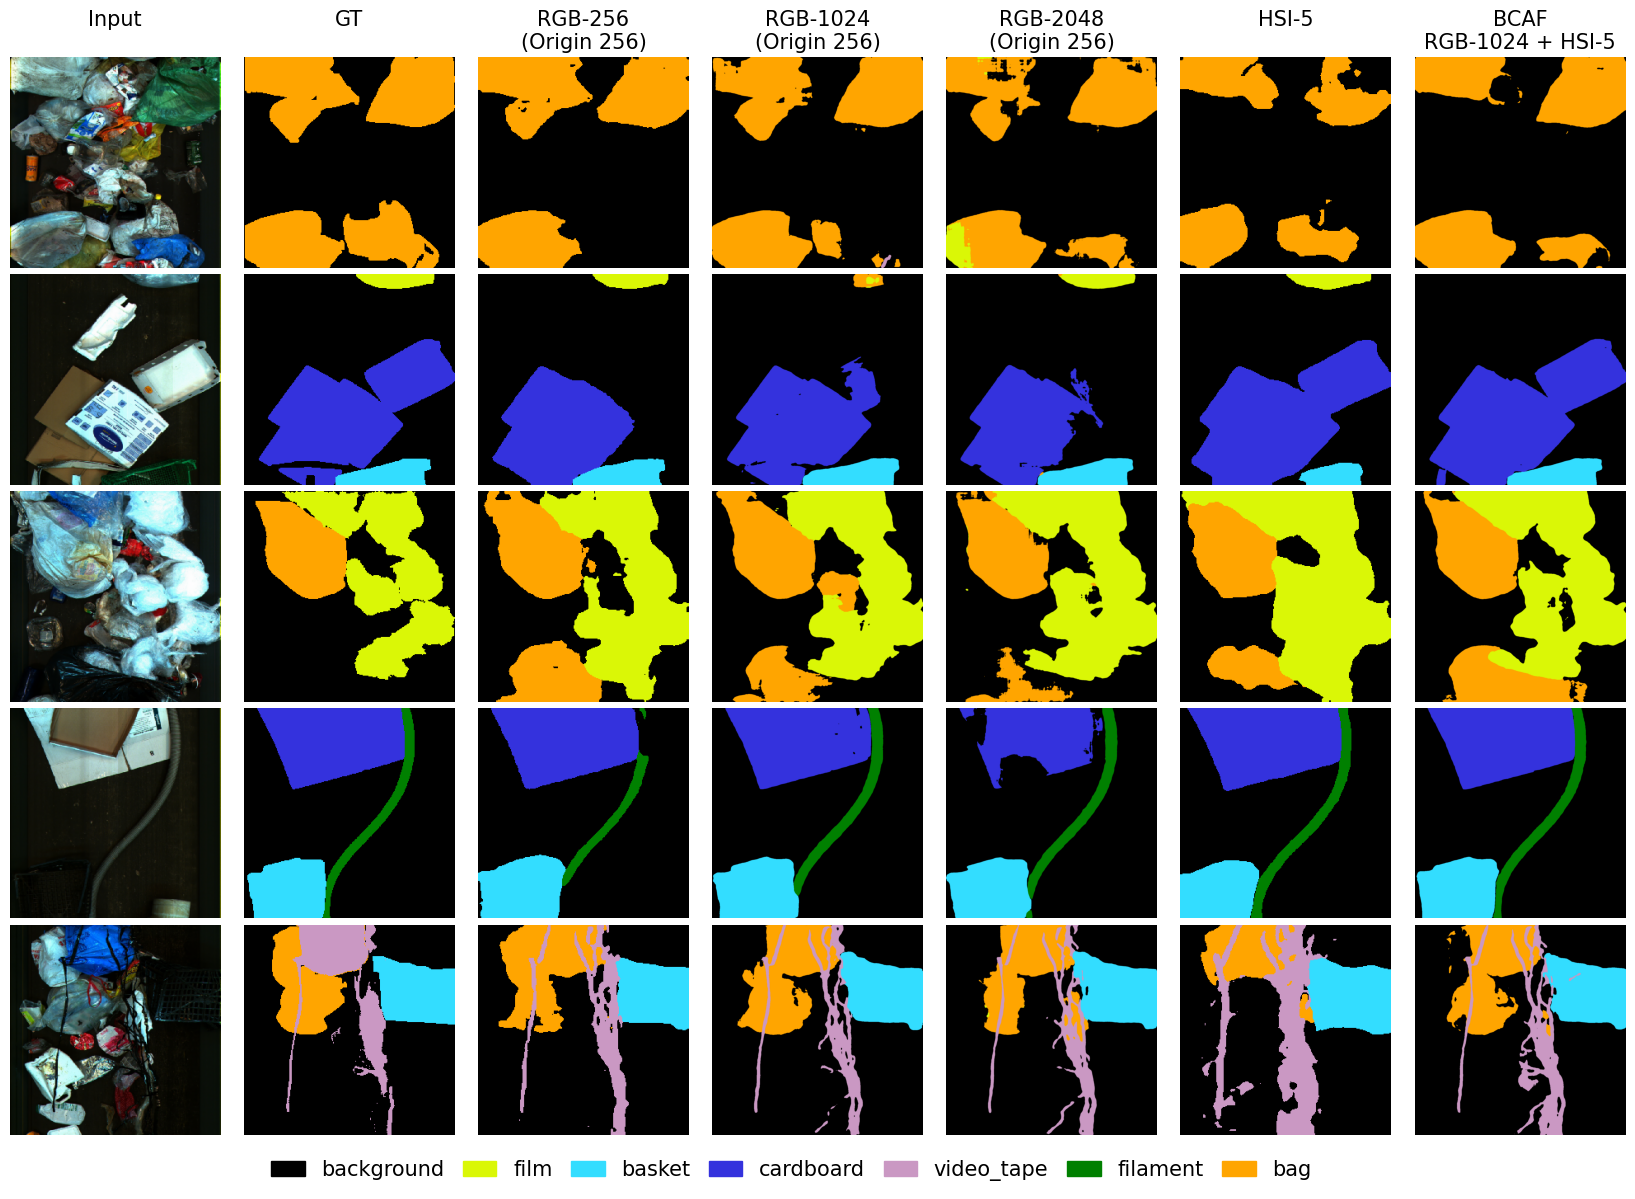

In [ ]:
# ==================== CELL 2: VISUALIZATION ====================

DEVICE = os.environ.get("EVAL_GPU", "6")

# Define models to visualize
visualization_models = [
    {
        'name': 'rgb_256',
        'config': '/home/jon86439/Final_MA/SpectralWaste/configs/RGB/swin_t_rgb_256.yaml',
        'checkpoint': '/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_256/swin_t_SpectralWaste_rgb_256_2_best.pth',
        'title': 'RGB-256\n(Origin 256)'
    },
    {
        'name': 'rgb_1024',
        'config': '/home/jon86439/Final_MA/SpectralWaste/configs/RGB/swin_t_rgb_1024.yaml',
        'checkpoint': '/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_1024/swin_t_SpectralWaste_rgb_1024_2_best.pth',
        'title': 'RGB-1024\n(Origin 256)'
    },
    {
        'name': 'rgb_2048',
        'config': '/home/jon86439/Final_MA/SpectralWaste/configs/RGB/swin_t_rgb_2048.yaml',
        'checkpoint': '/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_2048/swin_t_SpectralWaste_rgb_2048_2_best.pth',
        'title': 'RGB-2048\n(Origin 256)'
    },
    {
        'name': 'hsi_5',
        'config': '/home/jon86439/Final_MA/SpectralWaste/configs/HSI/adapted_swin_T_HSI_5.yaml',
        'checkpoint': '/home/jon86439/Final_MA/SpectralWaste/models/HSI/HSI_5/adapted_swin_t_SpectralWaste_hsi_5_run4_best.pth',
        'title': 'HSI-5\n'
    },
    {
        'name': 'fusion_1024',
        'config': '/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/BCAF_RGB_1024_HSI_5.yaml',
        'checkpoint': '/home/jon86439/Final_MA/SpectralWaste/models/Fusion/BCAF_1024/BCAF_SpectralWaste_rgb1024_hsi5_run2_best.pth',
        'title': 'BCAF\nRGB-1024 + HSI-5'
    },
]

input_idxs = [0, 165, 79, 166, 118]

# Optional: Print metrics for each model
print("="*80)
print("COMPUTING METRICS FOR VISUALIZATION MODELS")
print("="*80)

for spec in visualization_models:
    print(f"\n=== {spec['title']} | GPU {DEVICE} ===", flush=True)
    model, config, test_ds, num_classes, class_names, device = build_and_load(
        spec['config'], spec['checkpoint'], device_id=DEVICE
    )
    m = evaluate_full(model, config, test_ds, num_classes, device, 
                     batch_size=1, show_progress=True)
    try: model.to("cpu")
    except: pass
    cleanup_cuda(device=device, vars_to_del=["model"])
    del model

# Visualize
print("\n" + "="*80)
print("GENERATING VISUALIZATION")
print("="*80 + "\n")

visualize_grid(visualization_models, input_idxs, device_id=DEVICE)

## grouped

In [2]:
# ==================== CELL 3: GROUPED EVALUATION ====================

DEVICE = os.environ.get("EVAL_GPU", "2")

# Define model groups
model_groups = {
#   "Swin T RGB 256": [
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/swin_t_rgb_256.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_256/swin_t_SpectralWaste_rgb_256_0_best.pth",
#          "Swin T RGB 256 -run0"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/swin_t_rgb_256.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_256/swin_t_SpectralWaste_rgb_256_1_best.pth",
#          "Swin T RGB 256 -run1"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/swin_t_rgb_256.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_256/swin_t_SpectralWaste_rgb_256_2_best.pth",
#          "Swin T RGB 256 -run2"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/swin_t_rgb_256.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_256/swin_t_SpectralWaste_rgb_256_3_best.pth",
#          "Swin T RGB 256 -run3"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/swin_t_rgb_256.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_256/swin_t_SpectralWaste_rgb_256_4_best.pth",
#          "Swin T RGB 256 -run4"),
# ],

#  "Swin T RGB 512": [
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/swin_t_rgb_512.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_512/swin_t_SpectralWaste_rgb_512_0_best.pth",
#          "Swin T RGB 512 -run0"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/swin_t_rgb_512.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_512/swin_t_SpectralWaste_rgb_512_1_best.pth",
#          "Swin T RGB 512 -run1"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/swin_t_rgb_512.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_512/swin_t_SpectralWaste_rgb_512_2_best.pth",
#          "Swin T RGB 512 -run2"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/swin_t_rgb_512.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_512/swin_t_SpectralWaste_rgb_512_3_best.pth",
#          "Swin T RGB 512 -run3"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/swin_t_rgb_512.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_512/swin_t_SpectralWaste_rgb_512_4_best.pth",
#          "Swin T RGB 512 -run4"),
# ],

#  "Swin T RGB 1024": [
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/swin_t_rgb_1024.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_1024/swin_t_SpectralWaste_rgb_1024_0_best.pth",
#          "Swin T RGB 1024 -run0"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/swin_t_rgb_1024.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_1024/swin_t_SpectralWaste_rgb_1024_1_best.pth",
#          "Swin T RGB 1024 -run1"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/swin_t_rgb_1024.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_1024/swin_t_SpectralWaste_rgb_1024_2_best.pth",
#          "Swin T RGB 1024 -run2"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/swin_t_rgb_1024.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_1024/swin_t_SpectralWaste_rgb_1024_3_best.pth",
#          "Swin T RGB 1024 -run3"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/swin_t_rgb_1024.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_1024/swin_t_SpectralWaste_rgb_1024_4_best.pth",
#          "Swin T RGB 1024 -run4"),
# ],

#   "Swin T RGB 2048": [
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/swin_t_rgb_2048.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_2048/swin_t_SpectralWaste_rgb_2048_0_best.pth",
#          "Swin T RGB 2048 -run0"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/swin_t_rgb_2048.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_2048/swin_t_SpectralWaste_rgb_2048_1_best.pth",
#          "Swin T RGB 2048 -run1"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/swin_t_rgb_2048.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_2048/swin_t_SpectralWaste_rgb_2048_2_best.pth",
#          "Swin T RGB 2048 -run2"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/swin_t_rgb_2048.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_2048/swin_t_SpectralWaste_rgb_2048_3_best.pth",
#          "Swin T RGB 2048 -run3"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/swin_t_rgb_2048.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_2048/swin_t_SpectralWaste_rgb_2048_4_best.pth",
#          "Swin T RGB 2048 -run4"),
# ],

#   "Segformer B0 RGB 256": [
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/segformer_b0_RGB_256.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_256/segformer_b0_SpectralWaste_rgb_256_0_best.pth",
#          "Segformer B0 RGB 256 -run0"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/segformer_b0_RGB_256.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_256/segformer_b0_SpectralWaste_rgb_256_1_best.pth",
#          "Segformer B0 RGB 256 -run1"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/segformer_b0_RGB_256.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_256/segformer_b0_SpectralWaste_rgb_256_2_best.pth",
#          "Segformer B0 RGB 256 -run2"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/segformer_b0_RGB_256.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_256/segformer_b0_SpectralWaste_rgb_256_3_best.pth",
#          "Segformer B0 RGB 256 -run3"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/segformer_b0_RGB_256.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_256/segformer_b0_SpectralWaste_rgb_256_4_best.pth",
#          "Segformer B0 RGB 256 -run4"),
# ],

#   "Segformer B0 RGB 1024": [
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/segformer_b0_RGB_1024.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_1024/segformer_b0_SpectralWaste_rgb_1024_0_best.pth",
#          "Segformer B0 RGB 1024 -run0"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/segformer_b0_RGB_1024.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_1024/segformer_b0_SpectralWaste_rgb_1024_1_best.pth",
#          "Segformer B0 RGB 1024 -run1"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/segformer_b0_RGB_1024.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_1024/segformer_b0_SpectralWaste_rgb_1024_2_best.pth",
#          "Segformer B0 RGB 1024 -run2"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/segformer_b0_RGB_1024.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_1024/segformer_b0_SpectralWaste_rgb_1024_3_best.pth",
#          "Segformer B0 RGB 1024 -run3"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/segformer_b0_RGB_1024.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_1024/segformer_b0_SpectralWaste_rgb_1024_4_best.pth",
#          "Segformer B0 RGB 1024 -run4"),
# ],



#   "Segformer B2 RGB  256": [
#         ("//home/jon86439/Final_MA/SpectralWaste/configs/RGB/segformer_b2_RGB_256.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_256/segformer_b2_SpectralWaste_rgb_256_0_best.pth",
#          "Segformer B2 RGB 256 -run0"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/segformer_b2_RGB_256.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_256/segformer_b2_SpectralWaste_rgb_256_1_best.pth",
#          "Segformer B2 RGB 256 -run1"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/segformer_b2_RGB_256.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_256/segformer_b2_SpectralWaste_rgb_256_2_best.pth",
#          "Segformer B2 RGB 256 -run2"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/segformer_b2_RGB_256.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_256/segformer_b2_SpectralWaste_rgb_256_3_best.pth",
#          "Segformer B2 RGB 256 -run3"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/segformer_b2_RGB_256.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_256/segformer_b2_SpectralWaste_rgb_256_4_best.pth",
#          "Segformer B2 RGB 256 -run4"),
# ],

#   "Segformer B2 RGB 1024": [
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/segformer_b2_RGB_1024.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_1024/segformer_b2_SpectralWaste_rgb_1024_0_best.pth",
#          "Segformer B2 RGB 1024 -run0"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/segformer_b2_RGB_1024.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_1024/segformer_b2_SpectralWaste_rgb_1024_1_best.pth",
#          "Segformer B2 RGB 1024 -run1"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/segformer_b2_RGB_1024.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_1024/segformer_b2_SpectralWaste_rgb_1024_2_best.pth",
#          "Segformer B2 RGB 1024 -run2"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/segformer_b2_RGB_1024.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_1024/segformer_b2_SpectralWaste_rgb_1024_3_best.pth",
#          "Segformer B2 RGB 1024 -run3"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/RGB/segformer_b2_RGB_1024.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/RGB/RGB_1024/segformer_b2_SpectralWaste_rgb_1024_4_best.pth",
#          "Segformer B2 RGB 1024 -run4"),
# ],

#   "Swin T HSI 1": [
#       ("/home/jon86439/Final_MA/SpectralWaste/configs/HSI/swin_T_HSI_1.yaml",
#                    "/home/jon86439/Final_MA/SpectralWaste/models/HSI/HSI_1/swin_t_SpectralWaste_hsi_1_run0_best.pth",
#                    "Swin T HSI 1 -run0"),
#                          ("/home/jon86439/Final_MA/SpectralWaste/configs/HSI/swin_T_HSI_1.yaml",
#                    "/home/jon86439/Final_MA/SpectralWaste/models/HSI/HSI_1/swin_t_SpectralWaste_hsi_1_run1_best.pth",
#                    "Swin T HSI 1 -run1"),
#                          ("/home/jon86439/Final_MA/SpectralWaste/configs/HSI/swin_T_HSI_1.yaml",
#                    "/home/jon86439/Final_MA/SpectralWaste/models/HSI/HSI_1/swin_t_SpectralWaste_hsi_1_run2_best.pth",
#                    "Swin T HSI 1 -run2"),
#                          ("/home/jon86439/Final_MA/SpectralWaste/configs/HSI/swin_T_HSI_1.yaml",
#                    "/home/jon86439/Final_MA/SpectralWaste/models/HSI/HSI_1/swin_t_SpectralWaste_hsi_1_run3_best.pth",
#                    "Swin T HSI 1 -run3"),
#                          ("/home/jon86439/Final_MA/SpectralWaste/configs/HSI/swin_T_HSI_1.yaml",
#                    "/home/jon86439/Final_MA/SpectralWaste/models/HSI/HSI_1/swin_t_SpectralWaste_hsi_1_run4_best.pth",
#                    "Swin T HSI 1 -run4"),
#   ],

#   "Adapted Swin T HSI 3": [
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/HSI/adapted_swin_T_HSI_3.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/HSI/HSI_3/adapted_swin_t_SpectralWaste_hsi_3_run0_best.pth",
#          "Adapted Swin T HSI 3 -run0"),
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/HSI/adapted_swin_T_HSI_3.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/HSI/HSI_3/adapted_swin_t_SpectralWaste_hsi_3_run1_best.pth",
#          "Adapted Swin T HSI 3 -run1"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/HSI/adapted_swin_T_HSI_3.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/HSI/HSI_3/adapted_swin_t_SpectralWaste_hsi_3_run2_best.pth",
#          "Adapted Swin T HSI 3 -run2"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/HSI/adapted_swin_T_HSI_3.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/HSI/HSI_3/adapted_swin_t_SpectralWaste_hsi_3_run3_best.pth",
#          "Adapted Swin T HSI 3 -run3"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/HSI/adapted_swin_T_HSI_3.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/HSI/HSI_3/adapted_swin_t_SpectralWaste_hsi_3_run4_best.pth",
#          "Adapted Swin T HSI 3 -run4"),
# ],

#   "Adapted Swin T HSI 5": [
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/HSI/adapted_swin_T_HSI_5.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/HSI/HSI_5/adapted_swin_t_SpectralWaste_hsi_5_run0_best.pth",
#          "Adapted Swin T HSI 5 -run0"),
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/HSI/adapted_swin_T_HSI_5.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/HSI/HSI_5/adapted_swin_t_SpectralWaste_hsi_5_run1_best.pth",
#          "Adapted Swin T HSI 5 -run1"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/HSI/adapted_swin_T_HSI_5.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/HSI/HSI_5/adapted_swin_t_SpectralWaste_hsi_5_run2_best.pth",
#          "Adapted Swin T HSI 5 -run2"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/HSI/adapted_swin_T_HSI_5.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/HSI/HSI_5/adapted_swin_t_SpectralWaste_hsi_5_run3_best.pth",
#          "Adapted Swin T HSI 5 -run3"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/HSI/adapted_swin_T_HSI_5.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/HSI/HSI_5/adapted_swin_t_SpectralWaste_hsi_5_run4_best.pth",
#          "Adapted Swin T HSI 5 -run4"),
# ],

#   "Adapted Swin T HSI 7": [
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/HSI/adapted_swin_T_HSI_7.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/HSI/HSI_7/adapted_swin_t_SpectralWaste_hsi_7_run0_best.pth",
#          "Adapted Swin T HSI 7 -run0"),
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/HSI/adapted_swin_T_HSI_7.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/HSI/HSI_7/adapted_swin_t_SpectralWaste_hsi_7_run1_best.pth",
#          "Adapted Swin T HSI 7 -run1"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/HSI/adapted_swin_T_HSI_7.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/HSI/HSI_7/adapted_swin_t_SpectralWaste_hsi_7_run2_best.pth",
#          "Adapted Swin T HSI 7 -run2"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/HSI/adapted_swin_T_HSI_7.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/HSI/HSI_7/adapted_swin_t_SpectralWaste_hsi_7_run3_best.pth",
#          "Adapted Swin T HSI 7 -run3"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/HSI/adapted_swin_T_HSI_7.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/HSI/HSI_7/adapted_swin_t_SpectralWaste_hsi_7_run4_best.pth",
#          "Adapted Swin T HSI 7 -run4"),
# ],

#   "Adapted Swin T HSI 10": [
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/HSI/adapted_swin_T_HSI_10.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/HSI/HSI_10/adapted_swin_t_SpectralWaste_hsi_10_run0_best.pth",
#          "Adapted Swin T HSI 10 -run0"),
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/HSI/adapted_swin_T_HSI_10.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/HSI/HSI_10/adapted_swin_t_SpectralWaste_hsi_10_run1_best.pth",
#          "Adapted Swin T HSI 10 -run1"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/HSI/adapted_swin_T_HSI_10.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/HSI/HSI_10/adapted_swin_t_SpectralWaste_hsi_10_run2_best.pth",
#          "Adapted Swin T HSI 10 -run2"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/HSI/adapted_swin_T_HSI_10.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/HSI/HSI_10/adapted_swin_t_SpectralWaste_hsi_10_run3_best.pth",
#          "Adapted Swin T HSI 10 -run3"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/HSI/adapted_swin_T_HSI_10.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/HSI/HSI_10/adapted_swin_t_SpectralWaste_hsi_10_run4_best.pth",
#          "Adapted Swin T HSI 10 -run4"),
# ],



#   "BCAF RGB 256 - HSI 5": [
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/BCAF_RGB_256_HSI_5.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/BCAF_256/BCAF_SpectralWaste_rgb256_hsi5_run0_best.pth",
#          "BCAF RGB 256 - HSI 5 -run0"),
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/BCAF_RGB_256_HSI_5.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/BCAF_256/BCAF_SpectralWaste_rgb256_hsi5_run1_best.pth",
#          "BCAF RGB 256 - HSI 5 -run1"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/BCAF_RGB_256_HSI_5.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/BCAF_256/BCAF_SpectralWaste_rgb256_hsi5_run2_best.pth",
#          "BCAF RGB 256 - HSI 5 -run2"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/BCAF_RGB_256_HSI_5.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/BCAF_256/BCAF_SpectralWaste_rgb256_hsi5_run3_best.pth",
#          "BCAF RGB 256 - HSI 5 -run3"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/BCAF_RGB_256_HSI_5.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/BCAF_256/BCAF_SpectralWaste_rgb256_hsi5_run4_best.pth",
#          "BCAF RGB 256 - HSI 5 -run4"),
# ],


#   "BCAF RGB 512 - HSI 5": [
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/BCAF_RGB_512_HSI_5.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/BCAF_512/BCAF_SpectralWaste_rgb512_hsi5_run0_best.pth",
#          "BCAF RGB 512 - HSI 5 -run0"),
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/BCAF_RGB_512_HSI_5.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/BCAF_512/BCAF_SpectralWaste_rgb512_hsi5_run1_best.pth",
#          "BCAF RGB 512 - HSI 5 -run1"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/BCAF_RGB_512_HSI_5.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/BCAF_512/BCAF_SpectralWaste_rgb512_hsi5_run2_best.pth",
#          "BCAF RGB 512 - HSI 5 -run2"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/BCAF_RGB_512_HSI_5.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/BCAF_512/BCAF_SpectralWaste_rgb512_hsi5_run3_best.pth",
#          "BCAF RGB 512 - HSI 5 -run3"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/BCAF_RGB_512_HSI_5.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/BCAF_512/BCAF_SpectralWaste_rgb512_hsi5_run4_best.pth",
#          "BCAF RGB 512 - HSI 5 -run4"),
# ],

  "BCAF RGB 1024 - HSI 1": [
        ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/BCAF_RGB_1024_HSI_1.yaml",
         "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/BCAF_1024/BCAF_SpectralWaste_rgb1024_hsi1_run0_best.pth",
         "BCAF RGB 1024 - HSI 1 -run0"),
        ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/BCAF_RGB_1024_HSI_1_run1.yaml",
         "/home/jon86439/BCAF/models/final/SpectralWaste_BCAF_RGB_1024_HSI_1_run1_best.pth",
         "BCAF RGB 1024 - HSI 1 -run1"),
                 ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/BCAF_RGB_1024_HSI_1_run2.yaml",
         "/home/jon86439/BCAF/models/final/SpectralWaste_BCAF_RGB_1024_HSI_1_run2_best.pth",
         "BCAF RGB 1024 - HSI 1 -run2"),
                 ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/BCAF_RGB_1024_HSI_1_run3.yaml",
         "/home/jon86439/BCAF/models/final/SpectralWaste_BCAF_RGB_1024_HSI_1_run3_best.pth",
         "BCAF RGB 1024 - HSI 1 -run3"),
                 ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/BCAF_RGB_1024_HSI_1_run4.yaml",
         "/home/jon86439/BCAF/models/final/SpectralWaste_BCAF_RGB_1024_HSI_1_run4_best.pth",
         "BCAF RGB 1024 - HSI 1 -run4"),
  ],


#   "BCAF RGB 1024 - HSI 5": [
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/BCAF_RGB_1024_HSI_5.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/BCAF_1024/BCAF_SpectralWaste_rgb1024_hsi5_run0_best.pth",
#          "BCAF RGB 1024 - HSI 5 -run0"),
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/BCAF_RGB_1024_HSI_5.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/BCAF_1024/BCAF_SpectralWaste_rgb1024_hsi5_run1_best.pth",
#          "BCAF RGB 1024 - HSI 5 -run1"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/BCAF_RGB_1024_HSI_5.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/BCAF_1024/BCAF_SpectralWaste_rgb1024_hsi5_run2_best.pth",
#          "BCAF RGB 1024 - HSI 5 -run2"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/BCAF_RGB_1024_HSI_5.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/BCAF_1024/BCAF_SpectralWaste_rgb1024_hsi5_run3_best.pth",
#          "BCAF RGB 1024 - HSI 5 -run3"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/BCAF_RGB_1024_HSI_5.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/BCAF_1024/BCAF_SpectralWaste_rgb1024_hsi5_run4_best.pth",
#          "BCAF RGB 1024 - HSI 5 -run4"),
# ],

#   "Logit Fusion RGB 1024 - HSI 5": [
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/logitfusion_RGB_1024_HSI_5.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/Logit_Fusion_1024/logitfusion_SpectralWaste_rgb1024_hsi5_run0_best.pth",
#          "Logit Fusion RGB 1024 - HSI 5 -run0"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/logitfusion_RGB_1024_HSI_5.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/Logit_Fusion_1024/logitfusion_SpectralWaste_rgb1024_hsi5_run1_best.pth",
#          "Logit Fusion RGB 1024 - HSI 5 -run1"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/logitfusion_RGB_1024_HSI_5.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/Logit_Fusion_1024/logitfusion_SpectralWaste_rgb1024_hsi5_run2_best.pth",
#          "Logit Fusion RGB 1024 - HSI 5 -run2"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/logitfusion_RGB_1024_HSI_5.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/Logit_Fusion_1024/logitfusion_SpectralWaste_rgb1024_hsi5_run3_best.pth",
#          "Logit Fusion RGB 1024 - HSI 5 -run3"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/logitfusion_RGB_1024_HSI_5.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/Logit_Fusion_1024/logitfusion_SpectralWaste_rgb1024_hsi5_run4_best.pth",
#          "Logit Fusion RGB 1024 - HSI 5 -run4"),
# ],

#   "Adapted Swin T HSI 5 - Ablation 111": [
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/adapted_swin_T_HSI_5_ablation111.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/111/adapted_swin_t_SpectralWaste_hsi_5_ablation111_run0_best.pth",
#          "Adapted Swin T HSI 5 - Ablation 111 -run0"),
#   ],

#     "Adapted Swin T HSI 5 - Ablation 311": [
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/adapted_swin_T_HSI_5_ablation311.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/311/adapted_swin_t_SpectralWaste_hsi_5_ablation311_run0_best.pth",
#          "Adapted Swin T HSI 5 - Ablation 311 -run0"),
#   ],

#   "Adapted Swin T HSI 5 - Ablation 212": [
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/adapted_swin_T_HSI_5_ablation212.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/212/adapted_swin_t_SpectralWaste_hsi_5_ablation212_run0_best.pth",
#          "Adapted Swin T HSI 5 - Ablation 212 -run0"),
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/adapted_swin_T_HSI_5_ablation212.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/212/adapted_swin_t_SpectralWaste_hsi_5_ablation212_run1_best.pth",
#          "Adapted Swin T HSI 5 - Ablation 212 -run1"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/adapted_swin_T_HSI_5_ablation212.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/212/adapted_swin_t_SpectralWaste_hsi_5_ablation212_run2_best.pth",
#          "Adapted Swin T HSI 5 - Ablation 212 -run2"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/adapted_swin_T_HSI_5_ablation212.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/212/adapted_swin_t_SpectralWaste_hsi_5_ablation212_run3_best.pth",
#          "Adapted Swin T HSI 5 - Ablation 212 -run3"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/adapted_swin_T_HSI_5_ablation212.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/212/adapted_swin_t_SpectralWaste_hsi_5_ablation212_run4_best.pth",
#          "Adapted Swin T HSI 5 - Ablation 212 -run4"),
# ],

#   "Adapted Swin T HSI 5 - Ablation 221": [
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/adapted_swin_T_HSI_5_ablation221.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/221/adapted_swin_t_SpectralWaste_hsi_5_ablation221_run0_best.pth",
#          "Adapted Swin T HSI 5 - Ablation 221 -run0"),
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/adapted_swin_T_HSI_5_ablation221.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/221/adapted_swin_t_SpectralWaste_hsi_5_ablation221_run1_best.pth",
#          "Adapted Swin T HSI 5 - Ablation 221 -run1"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/adapted_swin_T_HSI_5_ablation221.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/221/adapted_swin_t_SpectralWaste_hsi_5_ablation221_run2_best.pth",
#          "Adapted Swin T HSI 5 - Ablation 221 -run2"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/adapted_swin_T_HSI_5_ablation221.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/221/adapted_swin_t_SpectralWaste_hsi_5_ablation221_run3_best.pth",
#          "Adapted Swin T HSI 5 - Ablation 221 -run3"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/adapted_swin_T_HSI_5_ablation221.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/221/adapted_swin_t_SpectralWaste_hsi_5_ablation221_run4_best.pth",
#          "Adapted Swin T HSI 5 - Ablation 221 -run4"),
# ],

#   "Adapted Swin T HSI 5 - Ablation PCA": [
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/adapted_swin_T_HSI_5_ablationPCA.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/PCA/adapted_swin_t_SpectralWaste_hsi_5_ablationPCA_run0_best.pth",
#          "Adapted Swin T HSI 5 - Ablation PCA -run0"),
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/adapted_swin_T_HSI_5_ablationPCA.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/PCA/adapted_swin_t_SpectralWaste_hsi_5_ablationPCA_run1_best.pth",
#          "Adapted Swin T HSI 5 - Ablation PCA -run1"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/adapted_swin_T_HSI_5_ablationPCA.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/PCA/adapted_swin_t_SpectralWaste_hsi_5_ablationPCA_run2_best.pth",
#          "Adapted Swin T HSI 5 - Ablation PCA -run2"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/adapted_swin_T_HSI_5_ablationPCA.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/PCA/adapted_swin_t_SpectralWaste_hsi_5_ablationPCA_run3_best.pth",
#          "Adapted Swin T HSI 5 - Ablation PCA -run3"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/adapted_swin_T_HSI_5_ablationPCA.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/PCA/adapted_swin_t_SpectralWaste_hsi_5_ablationPCA_run4_best.pth",
#          "Adapted Swin T HSI 5 - Ablation PCA -run4"),
# ],

#   "Adapted Swin T HSI 5 - Ablation savgol PCA": [
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/adapted_swin_T_HSI_5_ablationsavgolPCA.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/savgol_PCA/adapted_swin_t_SpectralWaste_hsi_5_ablationsavgolPCA_run0_best.pth",
#          "Adapted Swin T HSI 5 - Ablation savgol PCA -run0"),
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/adapted_swin_T_HSI_5_ablationsavgolPCA.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/savgol_PCA/adapted_swin_t_SpectralWaste_hsi_5_ablationsavgolPCA_run1_best.pth",
#          "Adapted Swin T HSI 5 - Ablation savgol PCA -run1"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/adapted_swin_T_HSI_5_ablationsavgolPCA.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/savgol_PCA/adapted_swin_t_SpectralWaste_hsi_5_ablationsavgolPCA_run2_best.pth",
#          "Adapted Swin T HSI 5 - Ablation savgol PCA -run2"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/adapted_swin_T_HSI_5_ablationsavgolPCA.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/savgol_PCA/adapted_swin_t_SpectralWaste_hsi_5_ablationsavgolPCA_run3_best.pth",
#          "Adapted Swin T HSI 5 - Ablation savgol PCA -run3"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/adapted_swin_T_HSI_5_ablationsavgolPCA.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/savgol_PCA/adapted_swin_t_SpectralWaste_hsi_5_ablationsavgolPCA_run4_best.pth",
#          "Adapted Swin T HSI 5 - Ablation savgol PCA -run4"),
# ],

#   "BCAF RGB 1024 - HSI 5 - Ablation Stage 0 ": [
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/BCAF_RGB_1024_HSI_5_stage_0.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/fusion_stages/SpectralWaste_BCAF_1024_run0_stage_0_best.pth",
#          "BCAF RGB 1024 - HSI 5 - Ablation Stage 0 -run0"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/BCAF_RGB_1024_HSI_5_stage_0.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/fusion_stages/SpectralWaste_BCAF_1024_run1_stage_0_best.pth",
#          "BCAF RGB 1024 - HSI 5 - Ablation Stage 0 -run1"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/BCAF_RGB_1024_HSI_5_stage_0.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/fusion_stages/SpectralWaste_BCAF_1024_run2_stage_0_best.pth",
#          "BCAF RGB 1024 - HSI 5 - Ablation Stage 0 -run2"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/BCAF_RGB_1024_HSI_5_stage_0.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/fusion_stages/SpectralWaste_BCAF_1024_run3_stage_0_best.pth",
#          "BCAF RGB 1024 - HSI 5 - Ablation Stage 0 -run3"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/BCAF_RGB_1024_HSI_5_stage_0.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/fusion_stages/SpectralWaste_BCAF_1024_run4_stage_0_best.pth",
#          "BCAF RGB 1024 - HSI 5 - Ablation Stage 0 -run4"),
#     ],

    
#   "BCAF RGB 1024 - HSI 5 - Ablation Stage 3 ": [
#         ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/BCAF_RGB_1024_HSI_5_stage_3.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/fusion_stages/SpectralWaste_BCAF_1024_run0_stage_3_best.pth",
#          "BCAF RGB 1024 - HSI 5 - Ablation Stage 3 -run0"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/BCAF_RGB_1024_HSI_5_stage_3.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/fusion_stages/SpectralWaste_BCAF_1024_run1_stage_3_best.pth",
#          "BCAF RGB 1024 - HSI 5 - Ablation Stage 3 -run1"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/BCAF_RGB_1024_HSI_5_stage_3.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/fusion_stages/SpectralWaste_BCAF_1024_run2_stage_3_best.pth",
#          "BCAF RGB 1024 - HSI 5 - Ablation Stage 3 -run2"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/BCAF_RGB_1024_HSI_5_stage_3.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/fusion_stages/SpectralWaste_BCAF_1024_run3_stage_3_best.pth",
#          "BCAF RGB 1024 - HSI 5 - Ablation Stage 3 -run3"),
#                  ("/home/jon86439/Final_MA/SpectralWaste/configs/Ablation/BCAF_RGB_1024_HSI_5_stage_3.yaml",
#          "/home/jon86439/Final_MA/SpectralWaste/models/Ablation/fusion_stages/SpectralWaste_BCAF_1024_run4_stage_3_best.pth",
#          "BCAF RGB 1024 - HSI 5 - Ablation Stage 3 -run4"),
#     ],

#   "BCAF RGB 1024 - HSI 5 - Ablation HSI to RGB": [
#         ("/home/jon86439/BCAF/training_scripts/configs/SpectralWaste/finetune/Fusion/BCAF_hsi_to_rgb.yaml",
#          "/home/jon86439/BCAF/models/fusion/BCAF_hsi_to_rgb_run0_best.pth",
#          "BCAF RGB 1024 - HSI 5 - Ablation HSI to RGB -run0"),
#         ("/home/jon86439/BCAF/training_scripts/configs/SpectralWaste/finetune/Fusion/BCAF_hsi_to_rgb.yaml",
#          "/home/jon86439/BCAF/models/fusion/BCAF_hsi_to_rgb_run1_best.pth",
#          "BCAF RGB 1024 - HSI 5 - Ablation HSI to RGB -run1"),
#     ],

#   "BCAF RGB 1024 - HSI 5 - Ablation RGB to HSI": [
#         ("/home/jon86439/BCAF/training_scripts/configs/SpectralWaste/finetune/Fusion/BCAF_rgb_to_hsi.yaml",
#          "/home/jon86439/BCAF/models/fusion/BCAF_rgb_to_hsi_run0_best.pth",
#          "BCAF RGB 1024 - HSI 5 - Ablation RGB to HSI -run0"),
#         ("/home/jon86439/BCAF/training_scripts/configs/SpectralWaste/finetune/Fusion/BCAF_rgb_to_hsi.yaml",
#          "/home/jon86439/BCAF/models/fusion/BCAF_rgb_to_hsi_run1_best.pth",
#          "BCAF RGB 1024 - HSI 5 - Ablation RGB to HSI -run1"),
#     ],

}

group_summaries = {}

print("="*80)
print("GROUPED EVALUATION - COMPUTING STATISTICS ACROSS RUNS")
print("="*80)

for group_name, items in model_groups.items():
    print(f"\n\n{'='*80}")
    print(f"GROUP: {group_name} ({len(items)} runs)")
    print(f"{'='*80}")
    
    miou_list, class_iou_list, acc_list, f1_list = [], [], [], []
    class_names_for_print = None

    for idx, (config_path_str, checkpoint_path_str, model_name) in enumerate(items):
        print(f"\n-- [{idx+1}/{len(items)}] {model_name} --")
        config_path = Path(config_path_str)
        checkpoint_path = Path(checkpoint_path_str)

        if not config_path.exists():
            print(f"  Skipping: config not found: {config_path}")
            continue
        if not checkpoint_path.exists():
            print(f"  Skipping: checkpoint not found: {checkpoint_path}")
            continue

        # Load and evaluate
        model, config, test_ds, num_classes, class_names, device = build_and_load(
            str(config_path), str(checkpoint_path), device_id=DEVICE
        )
        
        res = evaluate_full(
            model, config, test_ds, num_classes, device,
            batch_size=1, show_progress=True, print_results=True
        )

        if not res or 'miou' not in res:
            print("  Warning: Evaluation returned no mIoU; skipping this run.")
            continue

        miou_list.append(float(res['miou']))
        if 'class_iou' in res:
            class_iou_list.append(np.array(res['class_iou'], dtype=float))
        if 'accuracy' in res:
            acc_list.append(float(res['accuracy']))
        if 'f1' in res:
            f1_list.append(float(res['f1']))
        elif 'f1_macro' in res:
            f1_list.append(float(res['f1_macro']))

        if class_names_for_print is None:
            class_names_for_print = class_names

        # Cleanup
        try: model.to("cpu")
        except: pass
        cleanup_cuda(device=device, vars_to_del=["model"])
        del model

    if len(miou_list) == 0:
        print(f"\nNo successful evaluations in group '{group_name}'.")
        group_summaries[group_name] = None
        continue

    # Compute statistics
    miou_arr = np.array(miou_list, dtype=float)
    miou_mean, miou_std = miou_arr.mean(), miou_arr.std()

    acc_mean = acc_std = None
    if len(acc_list) > 0:
        acc_arr = np.array(acc_list, dtype=float)
        acc_mean, acc_std = acc_arr.mean(), acc_arr.std()

    f1_mean = f1_std = None
    if len(f1_list) > 0:
        f1_arr = np.array(f1_list, dtype=float)
        f1_mean, f1_std = f1_arr.mean(), f1_arr.std()

    class_iou_mean = class_iou_std = None
    if len(class_iou_list) > 0:
        class_iou_mat = np.stack(class_iou_list, axis=0)
        class_iou_mean = class_iou_mat.mean(axis=0)
        class_iou_std = class_iou_mat.std(axis=0)

    # Print group summary
    print("\n" + "="*60)
    print("GROUP SUMMARY")
    print("="*60)
    print(f"Runs: {len(miou_list)}")
    print(f"mIoU: {miou_mean:.4f} ± {miou_std:.4f}")
    if acc_mean is not None:
        print(f"Accuracy: {acc_mean:.4f} ± {acc_std:.4f}")
    if f1_mean is not None:
        print(f"F1 (Macro): {f1_mean:.4f} ± {f1_std:.4f}")

    if class_iou_mean is not None:
        overall_mean_class_iou = float(class_iou_mean.mean())
        overall_std_class_iou = float(class_iou_mean.std())
        print(f"\nMean class-wise IoU across classes: {overall_mean_class_iou:.4f} ± {overall_std_class_iou:.4f}")
        print("\nClass IoU (mean ± std):")
        for c_idx in range(len(class_iou_mean)):
            cname = class_names_for_print[c_idx] if class_names_for_print and c_idx < len(class_names_for_print) else f"class_{c_idx}"
            print(f"    {cname}: {class_iou_mean[c_idx]:.4f} ± {class_iou_std[c_idx]:.4f}")

    group_summaries[group_name] = {
        "n": len(miou_list),
        "miou_mean": miou_mean,
        "miou_std": miou_std,
        "acc_mean": acc_mean,
        "acc_std": acc_std,
        "f1_mean": f1_mean,
        "f1_std": f1_std,
        "class_iou_mean": class_iou_mean,
        "class_iou_std": class_iou_std,
        "class_names": class_names_for_print,
    }

# Final summary table
print("\n\n" + "="*100)
print("FINAL SUMMARY: Per-Group Aggregated Statistics")
print("="*100)

for g, summ in group_summaries.items():
    if not summ:
        print(f"\nGroup: {g}")
        print("  No successful runs.")
        continue
    print(f"\nGroup: {g}")
    print(f"  Runs: {summ['n']}")
    print(f"  mIoU: {summ['miou_mean']:.4f} ± {summ['miou_std']:.4f}")
    if summ['acc_mean'] is not None:
        print(f"  Accuracy: {summ['acc_mean']:.4f} ± {summ['acc_std']:.4f}")
    if summ['f1_mean'] is not None:
        print(f"  F1 (Macro): {summ['f1_mean']:.4f} ± {summ['f1_std']:.4f}")
    if summ['class_iou_mean'] is not None:
        overall_mean_class_iou = float(summ['class_iou_mean'].mean())
        overall_std_class_iou = float(summ['class_iou_mean'].std())
        print(f"  Mean class-wise IoU (macro): {overall_mean_class_iou:.4f} ± {overall_std_class_iou:.4f}")
        print("  Class IoU (mean ± std):")
        for c_idx, (c_mean, c_std) in enumerate(zip(summ['class_iou_mean'], summ['class_iou_std'])):
            cname = summ['class_names'][c_idx] if summ['class_names'] and c_idx < len(summ['class_names']) else f"class_{c_idx}"
            print(f"    {cname}: {c_mean:.4f} ± {c_std:.4f}")

print("\n" + "="*100)
print("GROUPED EVALUATION COMPLETE")
print("="*100 + "\n")

GROUPED EVALUATION - COMPUTING STATISTICS ACROSS RUNS


GROUP: BCAF RGB 1024 - HSI 1 (5 runs)

-- [1/5] BCAF RGB 1024 - HSI 1 -run0 --
[GPU 2] Loading dataset: SpectralWaste (modality=rgb_hsi) ...
[GPU 2] Dataset loaded: test=171, classes=7
[GPU 2] Loading model from checkpoint ...
[GPU 2] Model ready.
Loaded HSI stats: /home/jon86439/BCAF/training_scripts/configs/SpectralWaste/data/hsi_stats.yaml
SpectralWasteDataset (rgb_hsi, train): 514 files
SpectralWasteDataset (rgb_hsi, val): 167 files
SpectralWasteDataset (rgb_hsi, test): 171 files
Loaded 'SpectralWaste' | train=514 val=167 test=171 classes=7
[Eval] Evaluate model (shift_x=0, shift_y=0)
[Eval] Progress: 100%

[Eval] === Results (shift_x=0, shift_y=0) ===
[Eval] mIoU: 0.7508
[Eval] Per-class IoU:
  IoU[0 - background]: 0.9400
  IoU[1 - film]: 0.7944
  IoU[2 - basket]: 0.8383
  IoU[3 - cardboard]: 0.8338
  IoU[4 - video_tape]: 0.5093
  IoU[5 - filament]: 0.8032
  IoU[6 - bag]: 0.7258

-- [2/5] BCAF RGB 1024 - HSI 1 -run1 --
[GPU 2

## shifted

In [ ]:
# ==================== CELL 4: SHIFTED EVALUATION ====================

DEVICE = os.environ.get("EVAL_GPU", "6")

# Define model groups for shift evaluation
shift_model_groups = {
      "BCAF RGB 1024 - HSI 5": [
        ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/BCAF_RGB_1024_HSI_5.yaml",
         "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/BCAF_1024/BCAF_SpectralWaste_rgb1024_hsi5_run0_best.pth",
         "BCAF RGB 1024 - HSI 5 -run0"),
        ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/BCAF_RGB_1024_HSI_5.yaml",
         "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/BCAF_1024/BCAF_SpectralWaste_rgb1024_hsi5_run1_best.pth",
         "BCAF RGB 1024 - HSI 5 -run1"),
                 ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/BCAF_RGB_1024_HSI_5.yaml",
         "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/BCAF_1024/BCAF_SpectralWaste_rgb1024_hsi5_run2_best.pth",
         "BCAF RGB 1024 - HSI 5 -run2"),
                 ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/BCAF_RGB_1024_HSI_5.yaml",
         "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/BCAF_1024/BCAF_SpectralWaste_rgb1024_hsi5_run3_best.pth",
         "BCAF RGB 1024 - HSI 5 -run3"),
                 ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/BCAF_RGB_1024_HSI_5.yaml",
         "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/BCAF_1024/BCAF_SpectralWaste_rgb1024_hsi5_run4_best.pth",
         "BCAF RGB 1024 - HSI 5 -run4"),
],
  "Logit Fusion RGB 1024 - HSI 5": [
        ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/logitfusion_RGB_1024_HSI_5.yaml",
         "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/Logit_Fusion_1024/logitfusion_SpectralWaste_rgb1024_hsi5_run0_best.pth",
         "Logit Fusion RGB 1024 - HSI 5 -run0"),
                 ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/logitfusion_RGB_1024_HSI_5.yaml",
         "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/Logit_Fusion_1024/logitfusion_SpectralWaste_rgb1024_hsi5_run1_best.pth",
         "Logit Fusion RGB 1024 - HSI 5 -run1"),
                 ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/logitfusion_RGB_1024_HSI_5.yaml",
         "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/Logit_Fusion_1024/logitfusion_SpectralWaste_rgb1024_hsi5_run2_best.pth",
         "Logit Fusion RGB 1024 - HSI 5 -run2"),
                 ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/logitfusion_RGB_1024_HSI_5.yaml",
         "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/Logit_Fusion_1024/logitfusion_SpectralWaste_rgb1024_hsi5_run3_best.pth",
         "Logit Fusion RGB 1024 - HSI 5 -run3"),
                 ("/home/jon86439/Final_MA/SpectralWaste/configs/Fusion/logitfusion_RGB_1024_HSI_5.yaml",
         "/home/jon86439/Final_MA/SpectralWaste/models/Fusion/Logit_Fusion_1024/logitfusion_SpectralWaste_rgb1024_hsi5_run4_best.pth",
         "Logit Fusion RGB 1024 - HSI 5 -run4"),
],
}

# Shift configurations to test
shift_configs = [
    (0, 0),      # No shift (baseline)
    (2, 2),      # 2 pixels right and down
    (4, 4),      # 4 pixels right and down
    (8, 8),      # 8 pixels right and down
    (16, 16),    # 16 pixels right and down
    (32, 32),    # 32 pixels right and down
    (64, 64),    # 64 pixels right and down
]

input_idxs = [0, 165, 79, 166, 118]

# Store results
results_table = {}

print("="*80)
print("SHIFTED EVALUATION - TESTING HSI MISALIGNMENT ROBUSTNESS")
print("="*80)

for group_name, checkpoints in shift_model_groups.items():
    print(f"\n{'='*80}")
    print(f"GROUP: {group_name} ({len(checkpoints)} checkpoints)")
    print(f"{'='*80}")
    
    results_table[group_name] = {}
    
    for shift_x, shift_y in shift_configs:
        print(f"\n{'='*60}")
        print(f"  Shift X={shift_x}, Y={shift_y}")
        print(f"{'='*60}\n")
        
        shift_key = f"({shift_x}, {shift_y})"
        run_mious = []
        
        # Evaluate each checkpoint
        for config_path, checkpoint_path, run_name in checkpoints:
            print(f"  [{run_name}] Evaluating...")
            model, config, test_ds, num_classes, class_names, device = build_and_load(
                config_path, checkpoint_path, device_id=DEVICE
            )
            
            m = evaluate_full(
                model, config, test_ds, num_classes, device, 
                batch_size=1, show_progress=True, 
                shift_x=shift_x, shift_y=shift_y,
                print_results=False
            )
            
            run_mious.append(m['miou'])
            print(f"  [{run_name}] mIoU: {m['miou']:.4f}")
            
            try: model.to("cpu")
            except: pass
            cleanup_cuda(device=device, vars_to_del=["model"])
            del model
        
        # Compute statistics across runs
        mean_miou = np.mean(run_mious)
        std_miou = np.std(run_mious)
        
        results_table[group_name][shift_key] = {
            'runs': run_mious,
            'mean': mean_miou,
            'std': std_miou,
            'class_iou': m['class_iou'],
            'class_names': class_names
        }
        
        print(f"\n  [{group_name}] {shift_key}: {mean_miou:.4f} ± {std_miou:.4f} (n={len(run_mious)})")

# Visualization: Select best checkpoint per group
print("\n\n" + "="*80)
print("VISUALIZATION: Selecting representative checkpoint per group")
print("="*80)

visualize_models = []

for group_name, checkpoints in shift_model_groups.items():
    baseline_key = "(0, 0)"
    baseline_runs = results_table[group_name][baseline_key]['runs']
    
    best_idx = np.argmax(baseline_runs)
    config_path, checkpoint_path, run_name = checkpoints[best_idx]
    
    visualize_models.append({
        'name': f'{group_name}_best',
        'config': config_path,
        'checkpoint': checkpoint_path,
        'title': f'{group_name}\n(best: {run_name})'
    })
    
    print(f"{group_name}: Selected {run_name} (baseline mIoU={baseline_runs[best_idx]:.4f})")

# Visualize selected checkpoints across shifts
for shift_x, shift_y in shift_configs:
    print(f"\nVisualizing shift ({shift_x}, {shift_y})...")
    visualize_grid(visualize_models, input_idxs, device_id=DEVICE, 
                   shift_x=shift_x, shift_y=shift_y)

# Summary tables
print("\n\n" + "="*100)
print("FINAL SUMMARY: Mean mIoU ± Std across runs for each group")
print("="*100)

shift_labels = [f"({x}, {y})" for x, y in shift_configs]
header = f"{'Group':<40} | " + " | ".join([f"{label:>15}" for label in shift_labels])
print(header)
print("-" * len(header))

for group_name in shift_model_groups.keys():
    row = f"{group_name:<40} | "
    values = []
    for label in shift_labels:
        mean = results_table[group_name][label]['mean']
        std = results_table[group_name][label]['std']
        values.append(f"{mean:.4f}±{std:.4f}")
    row += " | ".join([f"{v:>15}" for v in values])
    print(row)

# Degradation from baseline
print("\n\n" + "="*100)
print("DEGRADATION from baseline (mean difference in mIoU points)")
print("="*100)
print(header)
print("-" * len(header))

for group_name in shift_model_groups.keys():
    baseline_mean = results_table[group_name]["(0, 0)"]['mean']
    row = f"{group_name:<40} | "
    degradations = []
    for label in shift_labels:
        current_mean = results_table[group_name][label]['mean']
        deg = baseline_mean - current_mean
        degradations.append(f"{deg:>15.4f}")
    row += " | ".join(degradations)
    print(row)

# Percentage degradation
print("\n\n" + "="*100)
print("DEGRADATION from baseline (%) - (baseline - current) / baseline * 100")
print("="*100)
print(header)
print("-" * len(header))

for group_name in shift_model_groups.keys():
    baseline_mean = results_table[group_name]["(0, 0)"]['mean']
    row = f"{group_name:<40} | "
    degradations = []
    for label in shift_labels:
        current_mean = results_table[group_name][label]['mean']
        deg_pct = ((baseline_mean - current_mean) / baseline_mean) * 100 if baseline_mean > 0 else 0.0
        degradations.append(f"{deg_pct:>14.2f}%")
    row += " | ".join(degradations)
    print(row)

print("\n" + "="*100)
print("SHIFTED EVALUATION COMPLETE")
print("="*100 + "\n")